# **Predicting House Prices with Linear Regression**

In [1]:
import pandas as pd

In [2]:
# Import Dataset
df = pd.read_csv('AmesHousing.csv')

In [3]:
# Dataset Overview
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
# Dataset's size
df.shape

(2930, 82)

In [5]:
# Column Datatype
df.dtypes

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 82, dtype: object

In [6]:
df.describe

<bound method NDFrame.describe of       Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL           NaN      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [8]:
# Check the Null Value
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64

In [9]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [10]:
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [11]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


# Distribution of SalePrice

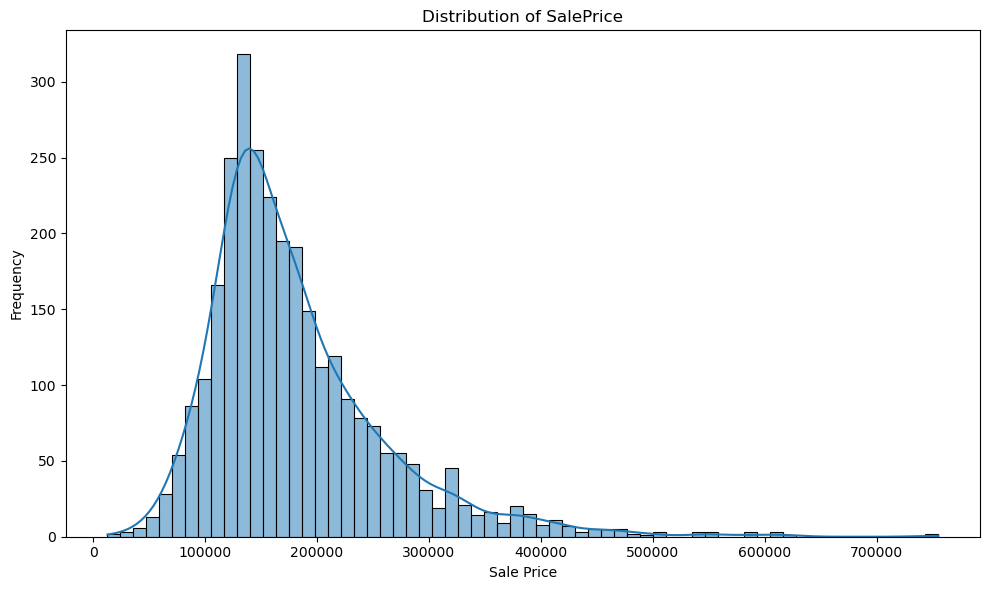

In [12]:
# Distribution of Target Variable (SalePrice)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Distribution of Target Variable (SalePrice)
## Output
- The histogram below shows the distribution of house sale prices in the Ames dataset.  
- Most properties are concentrated between **100,000 and 200,000**, while a smaller number of houses have much higher prices.  
- This indicates a **right-skewed distribution**, meaning that although most houses are moderately priced, 
- There are some expensive houses acting as outliers.

# Feature Selection

In [13]:
# Feature Selection
selected_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built','Full Bath', 'Year Remod/Add', 'Lot Area']

df[selected_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Lot Area          0.266549
Name: SalePrice, dtype: float64

## Feature Selection Discussion (with Correlation)
Correlation analysis with the target variable **SalePrice** shows that the following features are strong predictors:
- **Overall Qual (0.79)** → Strongest correlation; construction quality directly impacts price.  
- **Gr Liv Area (0.70)** → Larger living area strongly increases house value.  
- **Garage Cars (0.65) & Garage Area (0.64)** → Garage availability and size add significant value.  
- **Total Bsmt SF (0.63) & 1st Flr SF (0.62)** → More usable basement and first floor space increase price.  
- **Year Built (0.55) & Year Remod/Add (0.53)** → Newer or renovated houses are more expensive.  
- **Full Bath (0.54)** → More bathrooms contribute positively to price.  
- **Lot Area (0.26)** → Larger plot size has some effect, but weaker compared to other features.  
- These features capture **quality, size, age, and amenities**, which are the main drivers of housing prices.  
- Hence, they are selected as key predictors for building the regression model.
- Other columns like `Order` and `PID` are identifiers and not useful, while features with excessive missing values (e.g., Pool QC, Misc Feature, Alley) are excluded.

# Handling Missing Values

In [14]:
categorical_none_cols = [
    'Pool QC',
    'Misc Feature',
    'Alley',
    'Fence',
    'Mas Vnr Type',
    'Fireplace Qu',
    'Garage Type',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2']
df[categorical_none_cols] = df[categorical_none_cols].fillna('None')

In [15]:
zero_cols = [
    'Mas Vnr Area',
    'BsmtFin SF 1',
    'BsmtFin SF 2',
    'Bsmt Unf SF',
    'Total Bsmt SF',
    'Bsmt Full Bath',
    'Bsmt Half Bath',
    'Garage Cars',
    'Garage Area']
df[zero_cols] = df[zero_cols].fillna(0)

In [16]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(
    df['Lot Frontage'].median())

In [17]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [18]:
df['Electrical'] = df['Electrical'].fillna(
    df['Electrical'].mode()[0])

In [19]:
# Check Missing values after Handling it
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

## Missing Value Handling
Missing values were handled based on the meaning of each feature:
- **Categorical features:** Missing values in features such as Pool, Garage, Basement, Alley, Fence, etc. were replaced with `"None"` to indicate absence of the feature.
- **Numerical features:** Missing values related to absent property components, such as Garage, Basement, and Masonry, were replaced with `0`.
- **Lot Frontage:** Missing values were replaced with the **median** because they did not indicate absence of a feature.
- **Electrical:** The single missing value was replaced with the **mode**.
- **Garage Yr Blt:** Missing values were replaced with `0` when no garage was present.

After imputation, the dataset was checked and **no missing values remained**.

In [20]:
## Separating Features and Target Variable

X = df.drop(columns = ['SalePrice', 'Order', 'PID'])
y = df['SalePrice']

numeric_features = X.select_dtypes(include = ['int64', 'float64']).columns
categorical_features = X.select_dtypes(include = ['object']).columns

print('Numerical Features:', len(numeric_features))
print('Categorical Features:', len(categorical_features))

Numerical Features: 36
Categorical Features: 43


## Separating Features and Target Variable
- The target variable, `SalePrice`, was separated from the predictor variables.
-  The identifier columns `Order` and `PID` were excluded because they identify individual records and do not represent meaningful characteristics of the properties.
- The remaining features were divided into numerical and categorical variables for further preprocessing.
- Numerical Features: 36
- Categorical Features: 43

# One-Hot Encoding

In [21]:
## One-Hot Encoding 

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_features])

print("Encoded categorical data shape:", X_encoded.shape)

Encoded categorical data shape: (2930, 282)


## One-Hot Encoding of Categorical Features
- The categorical features were converted into numerical form using One-Hot Encoding.
-  This transformation creates separate binary columns for the different categories within each categorical feature.
- The `handle_unknown='ignore'` option was used so that unseen categories can be handled safely during model evaluation.

After encoding, the 43 categorical features were transformed into 282 numerical features.
- Original Categorical Features: 43
- Encoded Features: 282
- Number of Rows: 2,930

In [22]:
## Combining Numerical and Encoded Categorical Features
import numpy as np

X_numeric = X[numeric_features].to_numpy()
X_final = np.hstack([X_numeric, X_encoded])

print("Final feature matrix shape:", X_final.shape)

Final feature matrix shape: (2930, 318)


## Combining Numerical and Encoded Categorical Features
- The original numerical features and the one-hot encoded categorical features were combined into a single feature matrix.
- This provides a complete numerical representation of the predictor variables that can be used as input for the machine learning model.

The final feature matrix contains:
- 36 numerical features
- 282 encoded categorical features
- 318 total predictor features
- 2,930 observations

Therefore, the final feature matrix has a shape of 2930 × 318.

In [23]:
# Select numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation with SalePrice
correlation = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
correlation

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647562
Garage Area        0.640138
Total Bsmt SF      0.632529
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Mas Vnr Area       0.502196
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.433147
Lot Frontage       0.340256
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.275823
2nd Flr SF         0.269373
Lot Area           0.266549
Garage Yr Blt      0.253459
Bsmt Unf SF        0.183308
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.006018
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035817
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

# Correlation HeatMap

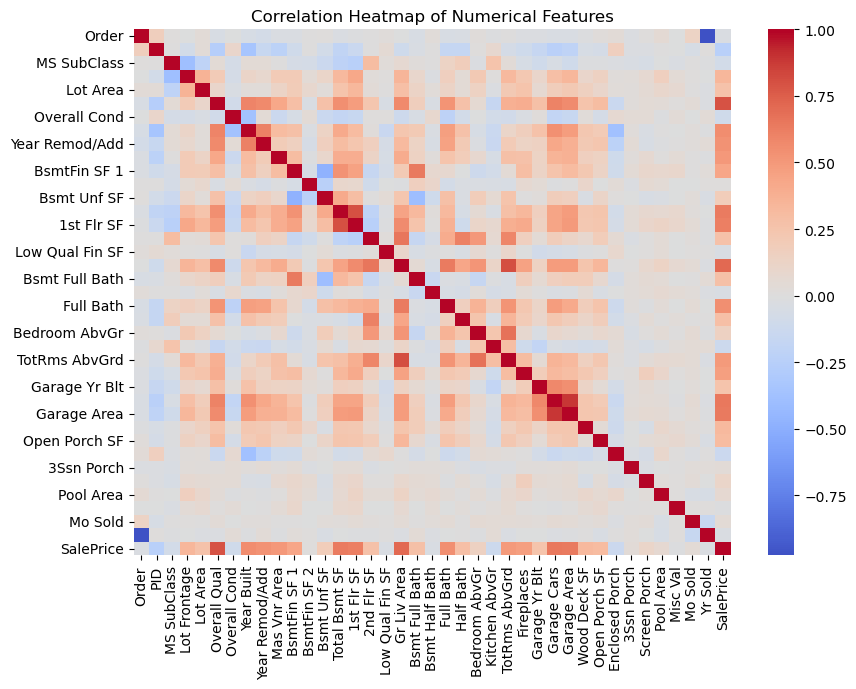

In [24]:
## HeatMap

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi = 150, bbox_inches = 'tight')
plt.show()

## Correlation Heatmap
The correlation heatmap was used to examine the relationships between numerical features and `SalePrice`.
- The analysis shows that `Overall Qual` has the strongest positive correlation with `SalePrice` (0.799), followed by `Gr Liv Area` (0.707), `Garage Cars` (0.648), `Garage Area` (0.640), `Total Bsmt SF` (0.633), and `1st Flr SF` (0.622).
- Other features such as `Year Built`, `Full Bath`, `Year Remod/Add`, and `Mas Vnr Area` also show moderate positive relationships with house prices.

- Overall, the heatmap indicates that **house quality, living area, garage features, basement area, and property age** are among the important numerical factors associated with house prices.
-  These correlations help in understanding the relationships between the features and the target variable before building the regression model.

# Train-Test Split (80/20)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size = 0.20, random_state = 42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (2344, 318)
X_test shape: (586, 318)
y_train shape: (2344,)
y_test shape: (586,)


## Train/Test Split (80/20)
The dataset was divided into training and testing sets to evaluate model performance on unseen data.  
- **Training set:** 80% of the data → used to fit the model.  
- **Testing set:** 20% of the data → used to validate the model’s generalization ability.  
A `random_state` of 42 was used to ensure that the same split can be reproduced consistently.
### Shapes of the Split
- **X_train:** (2344, 318) → 2344 samples, 318 features  
- **X_test:** (586, 318) → 586 samples, 318 features  
- **y_train:** (2344,) → target values for training set  
- **y_test:** (586,) → target values for testing set  

###  Conclusion
This split ensures that the model is trained on a large portion of the data while still being tested on a sufficient sample size.  
It helps prevent overfitting and provides a reliable estimate of model performance.

# Train a Linear Regression model

In [26]:
from sklearn.linear_model import LinearRegression

## Create Linear Regression model
model = LinearRegression()

In [27]:
## Train the model on training data

model.fit(X_train, y_train)
print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


## Training the Linear Regression Model
- A Linear Regression model was selected to predict house prices based on the available property features. 
- The model was trained using the training dataset (`X_train` and `y_train`).
- The model learns the relationship between the predictor variables and the target variable, `SalePrice`, by estimating coefficients for the input features.
- The trained model will later be used to predict house prices on the unseen test dataset and evaluate its performance.

# Model Evaluation using MSE, RMSE, R² score 

In [28]:
# Predict the house prices for the test data
y_pred = model.predict(X_test)
print('Prediction generated successfully')


Prediction generated successfully


In [29]:
from sklearn.metrics import mean_squared_error, r2_score

## Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

## Root mean squared error (RMSE)
rmse = np.sqrt(mse)

# R² score
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

Mean Squared Error: 844674495.2171519
Root Mean Squared Error: 29063.284315733345
R² Score: 0.8946467794771865


##  Model Evaluation (Linear Regression)
The Linear Regression model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score on the test dataset.
###  Results
- **Mean Squared Error (MSE):** 844,674,495.21  
- **Root Mean Squared Error (RMSE):** 29,063.28  
- **R² Score:** 0.8946  
###  Interpretation
- **MSE** represents the average squared difference between predicted and actual values.  
- **RMSE** indicates the average prediction error in terms of house price units (~29,000), which is reasonable given the price range.  
- **R² Score (~0.89)** shows that the model explains about **89% of the variance** in SalePrice, indicating a strong fit.

## Scatter Plot

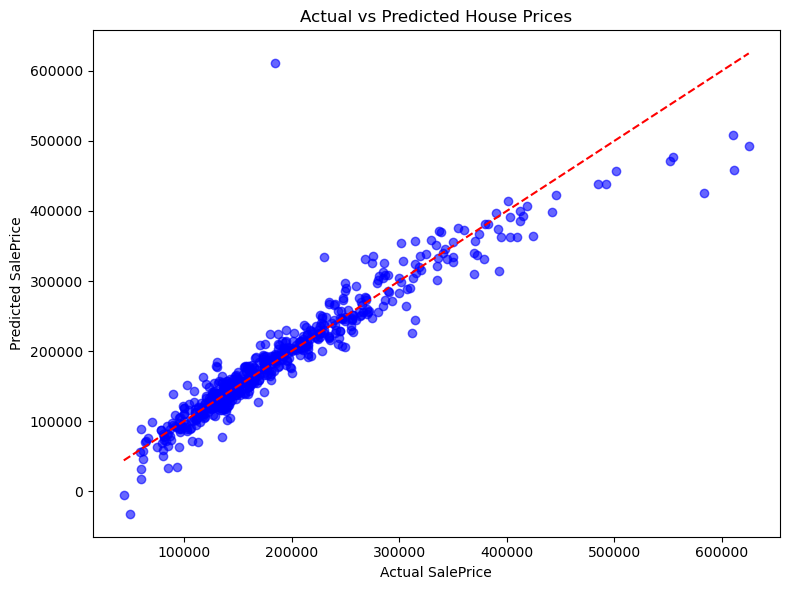

In [30]:
## Scatter Plot
plt.figure(figsize = (8, 6))

# Actual vs Predicted points 
plt.scatter(y_test, y_pred, alpha = 0.6, color = 'blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], linestyle = '--', color = 'red')           # Diagonal line
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

## Scatter Plot: Actual vs Predicted Prices
The scatter plot compares the **actual SalePrice values** with the **predicted SalePrice values** from the Linear Regression model.
### Observations
- Most points are clustered around the **diagonal red dashed line (y = x)**, indicating that predictions are close to actual values.  
- This alignment confirms that the model has captured the relationship between features and SalePrice effectively.  
- Some deviations are visible, especially at higher price ranges, which may be due to outliers or non-linear effects not fully captured by Linear Regression.
### Conclusion
The scatter plot visually demonstrates that the Linear Regression model performs well, with predictions closely matching actual house prices.  
This supports the earlier evaluation metrics (MSE, RMSE, R²) and validates the model’s reliability.

# Residual Plot

In [31]:
# Calculate Residual 
residuals = y_test - y_pred                              # residual = actual price - predicted price 
print('Residual calculated successfully')

Residual calculated successfully


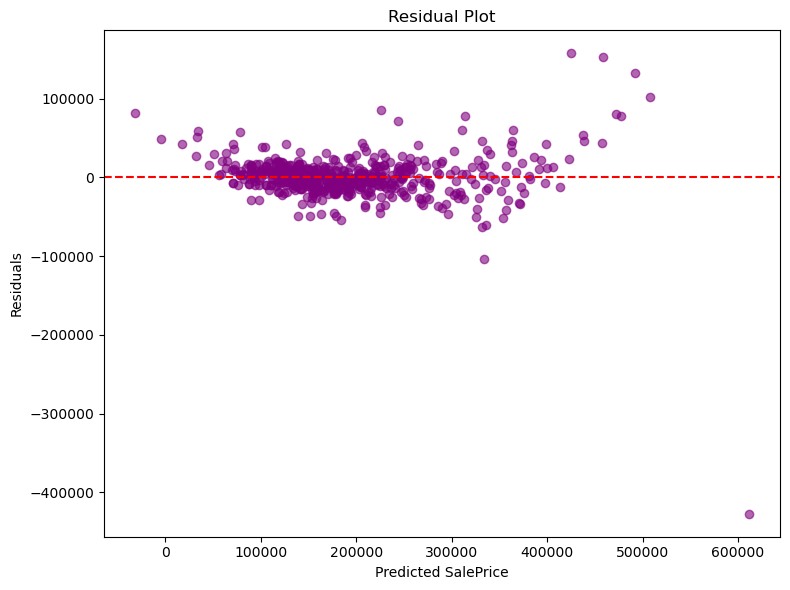

In [32]:
# Residual Plot
plt.figure(figsize = (8, 6))
plt.scatter(y_pred, residuals, alpha = 0.6, color = 'purple')
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## Residual Plot
The residual plot shows the distribution of errors (**residuals = actual − predicted**) against the predicted SalePrice values.
### Observations
- Most residuals are scattered randomly around the horizontal line at **y = 0**, which indicates that the model errors are unbiased.  
- No clear systematic pattern or curve is visible, supporting the assumption of linearity.  
- A few extreme residuals are present, suggesting possible outliers or houses with unusual characteristics.  
- The spread of residuals increases slightly at higher predicted prices, which may indicate heteroscedasticity (variance of errors increasing with price).
### Conclusion
- The residual plot confirms that the Linear Regression model errors are largely random, validating the model’s reliability.  
- However, the presence of outliers and slight heteroscedasticity suggests that advanced techniques (Ridge/Lasso regression or log transformation of SalePrice) could further improve performance.

# Coefficient Analysis

In [33]:
##  Create encoded feature matrix and feature name 
X_encoded_df = pd.get_dummies(X, columns = categorical_features, drop_first = False)
print('Encoded feature matrix shape:', X_encoded_df.shape)

Encoded feature matrix shape: (2930, 318)


In [34]:
# Get feature names 
feature_names = X_encoded_df.columns

## Create a DataFrame of feature coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficients': model.coef_})

# Sort coefficients
coefficients = coefficients.sort_values(by = 'Coefficients', ascending = False)

# Top 10 positie coefficients
coefficients.head(10)

,Feature,Coefficients
133,Roof Matl_Membran,129756.319356
299,Misc Feature_Othr,125556.732304
138,Roof Matl_WdShngl,116421.219705
134,Roof Matl_Metal,110765.204698
297,Misc Feature_Gar2,105448.269197
300,Misc Feature_Shed,103710.631581
298,Misc Feature_None,103221.449665
77,Neighborhood_GrnHill,100859.711294
135,Roof Matl_Roll,70922.952890
137,Roof Matl_WdShake,67856.491050


In [35]:
# Top 10 negative coefficients
coefficients.tail(10).sort_values(by='Coefficients', ascending=True)

,Feature,Coefficients
131,Roof Matl_ClyTile,-624027.955992
296,Misc Feature_Elev,-437937.082747
174,Mas Vnr Type_CBlock,-65134.817124
251,Functional_Sal,-61799.096068
277,Garage Cond_Ex,-52108.364368
289,Pool QC_None,-41365.831906
109,Condition 2_RRAe,-36840.271345
275,Garage Qual_Po,-27917.660820
167,Exterior 2nd_Stone,-27366.977914
66,Land Slope_Sev,-23701.727014


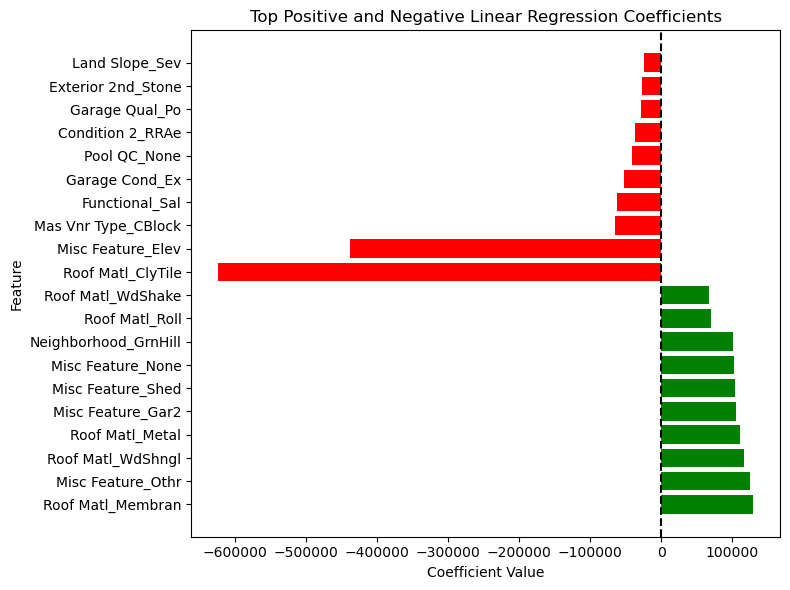

In [36]:
top_positive = coefficients.head(10)
top_negative = coefficients.tail(10).sort_values(by='Coefficients', ascending=True)

# Combine both
top_coefficients = pd.concat([top_positive, top_negative])

# Different colors for positive and negative values
colors = ['green' if value > 0 else 'red' 
          for value in top_coefficients['Coefficients']]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_coefficients['Feature'], top_coefficients['Coefficients'], color=colors)
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top Positive and Negative Linear Regression Coefficients')
plt.tight_layout()
plt.show()

## Coefficient Analysis
- Coefficient analysis was performed to understand the direction of the relationship between the features and predicted house prices.
- The coefficient analysis shows the features that have the highest positive and negative coefficients in the Linear Regression model.
- **Green bars (Positive coefficients):** These features are associated with higher predicted house prices relative to their reference categories.
- **Red bars (Negative coefficients):** These features are associated with lower predicted house prices relative to their reference categories.
- **Black dashed line:** Represents a coefficient value of zero.
- The plot shows that some categorical features have relatively large positive and negative coefficients.
- However, these values should be interpreted carefully because categorical variables were One-Hot Encoded, and their coefficients represent effects relative to reference categories. Rare categories may also result in unusually large coefficient values.
- Overall, the coefficient analysis helps understand the direction and relative contribution of features to the model's predicted house prices.

# Linear Regression vs Ridge Regression

In [37]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Ridge Regression
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_model.fit(X_train, y_train)

print("Ridge model trained successfully.")

Ridge model trained successfully.


In [38]:
# Predictions from all three models
linear_pred = model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [39]:
for name, pred in [('Linear Regression', linear_pred), ('Ridge Regression', ridge_pred)]:
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    
    print(f'{name}: MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}')

Linear Regression: MSE=844674495.22, RMSE=29063.28, R²=0.8946
Ridge Regression: MSE=846614193.89, RMSE=29096.64, R²=0.8944


## Linear vs Ridge Regression
Linear Regression and Ridge Regression were compared using **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**.
- **Linear Regression:** MSE = 844674495.22, RMSE = 29063.28, R² = 0.8946
- **Ridge Regression:** MSE = 846614193.89, RMSE = 29096.64, R² = 0.8944
### Comparison
- Linear Regression achieved a **lower MSE and RMSE** and a **slightly higher R² Score** than Ridge Regression. This indicates that Linear Regression provided slightly more accurate predictions on the test dataset.
- The difference between the two models is very small, showing that Ridge Regression performed almost similarly to Linear Regression. However, for this dataset, **Linear Regression was the better-performing model** based on the evaluation metrics.

# Business Recommendations
- Focus on key property attributes such as **Overall Quality, Living Area, Garage, Basement Area, and Year Built**, as they have a strong relationship with house prices.
- Use the model to estimate property prices and support **pricing and valuation decisions**.
- Real estate businesses can use these insights to identify properties with higher potential value.
- Ensure proper handling of missing values and categorical features before using the model for prediction.
- Regularly retrain the model with updated housing data to maintain prediction accuracy.

## Conclusion
- The project developed a Linear Regression model to predict house prices using property characteristics. After performing EDA, missing-value handling, One-Hot Encoding, and feature analysis, the model achieved an **R² score of 0.8946** with an **RMSE of 29,063.28**.
- Linear Regression performed slightly better than Ridge Regression on the test dataset. The results show that property quality, living area, garage, basement, and other structural features play an important role in determining house prices.
- Overall, the model provides a useful foundation for **data-driven house price estimation and real estate decision-making**.